In [1]:
import torch

print("=" * 80)
print("SYSTEM CHECK")
print("=" * 80)

print("PyTorch version :", torch.__version__)
print("TorchVision     :", __import__("torchvision").__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("CUDA version    :", torch.version.cuda)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device          :", device)

SYSTEM CHECK
PyTorch version : 2.11.0+cu128
TorchVision     : 0.26.0+cu128
CUDA available  : True
GPU             : Tesla T4
CUDA version    : 12.8
Device          : cuda


In [2]:
import os
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    WeightedRandomSampler
)

import torchvision

from torchvision import datasets, transforms

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
SEED = 42

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
# ============================================================
# DDR RESNET50 CONFIGURATION
# ============================================================

DATASET_NAME = "DDR"

MODEL_NAME = "ResNet50"

IMAGE_SIZE = 224

BATCH_SIZE = 16

EPOCHS = 50

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 5e-4

NUM_WORKERS = 2

EARLY_STOPPING_PATIENCE = 100

USE_OVERSAMPLING = True

CLASS_NAMES = ["0_No_DR", "1_Mild", "2_Moderate", "3_Severe", "4_Proliferative_DR"]

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 80)
print("EXPERIMENT CONFIGURATION")
print("=" * 80)

print("Dataset          :", DATASET_NAME)
print("Model            :", MODEL_NAME)
print("Image size       :", IMAGE_SIZE)
print("Batch size       :", BATCH_SIZE)
print("Epochs           :", EPOCHS)
print("Learning rate    :", LEARNING_RATE)
print("Weight decay     :", WEIGHT_DECAY)
print("Oversampling     :", USE_OVERSAMPLING)
print("Classes          :", CLASS_NAMES)

EXPERIMENT CONFIGURATION
Dataset          : DDR
Model            : ResNet50
Image size       : 224
Batch size       : 16
Epochs           : 50
Learning rate    : 0.0001
Weight decay     : 0.0005
Oversampling     : True
Classes          : ['0_No_DR', '1_Mild', '2_Moderate', '3_Severe', '4_Proliferative_DR']


In [5]:
KAGGLE_INPUT = Path("/kaggle/input")

print("Searching for prepared DDR dataset...")

candidates = []

for p in KAGGLE_INPUT.rglob("*"):

    if p.is_dir():

        if (
            (p / "train").is_dir()
            and
            (p / "val").is_dir()
            and
            (p / "test").is_dir()
        ):

            candidates.append(p)


print("\nCandidate dataset roots:")

for p in candidates:
    print(" ", p)


if len(candidates) == 0:

    raise FileNotFoundError(
        "Could not find a directory containing "
        "train/, val/, and test/ under /kaggle/input."
    )


# Prefer a path whose name contains DDR
ddr_candidates = [
    p for p in candidates
    if "ddr" in str(p).lower()
]


if len(ddr_candidates) > 0:

    DATA_ROOT = ddr_candidates[0]

else:

    DATA_ROOT = candidates[0]


print("\nSelected DDR dataset:")
print(DATA_ROOT)

Searching for prepared DDR dataset...

Candidate dataset roots:
  /kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr

Selected DDR dataset:
/kaggle/input/datasets/samjohnstonc/ddr-prepared/data/organized/ddr


In [6]:
print("=" * 80)
print("DDR DATASET STRUCTURE")
print("=" * 80)

for split in ["train", "val", "test"]:

    split_path = DATA_ROOT / split

    print(f"\n{split.upper()}")

    for cls in CLASS_NAMES:

        class_path = split_path / cls

        if not class_path.exists():

            print(
                f"  MISSING: {cls}"
            )

        else:

            count = len([
                f for f in class_path.iterdir()
                if f.is_file()
            ])

            print(
                f"  {cls:<22} {count}"
            )

DDR DATASET STRUCTURE

TRAIN
  0_No_DR                4933
  1_Mild                 504
  2_Moderate             3581
  3_Severe               189
  4_Proliferative_DR     730

VAL
  0_No_DR                616
  1_Mild                 63
  2_Moderate             448
  3_Severe               24
  4_Proliferative_DR     91

TEST
  0_No_DR                617
  1_Mild                 63
  2_Moderate             448
  3_Severe               23
  4_Proliferative_DR     92


In [7]:
def count_images(split_path):

    counts = {}

    for cls in CLASS_NAMES:

        class_dir = split_path / cls

        counts[cls] = len([
            f
            for f in class_dir.iterdir()
            if f.is_file()
        ])

    return counts


dataset_counts = {}

for split in ["train", "val", "test"]:

    dataset_counts[split] = count_images(
        DATA_ROOT / split
    )


count_df = pd.DataFrame(
    dataset_counts
).T

count_df["TOTAL"] = count_df.sum(
    axis=1
)

print(count_df)

       0_No_DR  1_Mild  2_Moderate  3_Severe  4_Proliferative_DR  TOTAL
train     4933     504        3581       189                 730   9937
val        616      63         448        24                  91   1242
test       617      63         448        23                  92   1243


In [8]:
import os
print(os.listdir(DATA_ROOT / "train"))

['3_Severe', '2_Moderate', '1_Mild', '0_No_DR', '4_Proliferative_DR']


In [9]:
expected_counts = {
    "train": 9937,
    "val": 1242,
    "test": 1243
}

for split in ["train", "val", "test"]:

    actual = count_df.loc[
        split,
        "TOTAL"
    ]

    expected = expected_counts[split]

    print(
        f"{split:<10} "
        f"Expected={expected:<6} "
        f"Actual={actual:<6}"
    )

    assert actual == expected


print("\nDDR dataset counts verified.")

train      Expected=9937   Actual=9937  
val        Expected=1242   Actual=1242  
test       Expected=1243   Actual=1243  

DDR dataset counts verified.


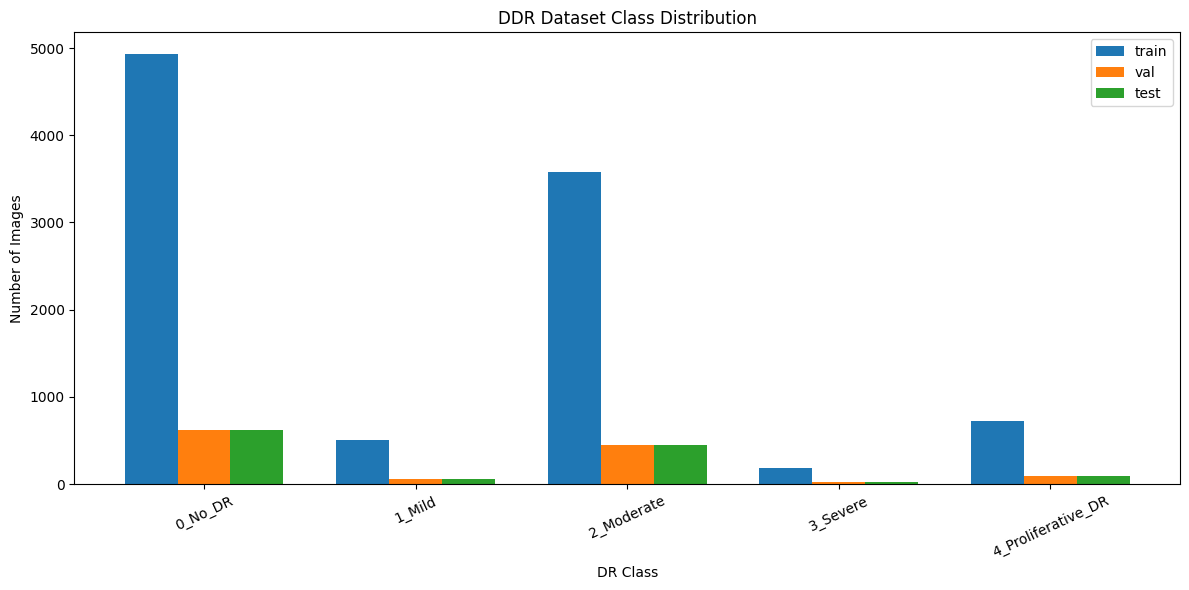

In [10]:
plt.figure(figsize=(12, 6))

x = np.arange(
    len(CLASS_NAMES)
)

width = 0.25

for i, split in enumerate(
    ["train", "val", "test"]
):

    values = [
        dataset_counts[split][cls]
        for cls in CLASS_NAMES
    ]

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=split
    )


plt.xticks(
    x,
    CLASS_NAMES,
    rotation=25
)

plt.ylabel(
    "Number of Images"
)

plt.xlabel(
    "DR Class"
)

plt.title(
    "DDR Dataset Class Distribution"
)

plt.legend()

plt.tight_layout()

plt.show()

In [11]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


print("ImageNet mean:", IMAGENET_MEAN)
print("ImageNet std :", IMAGENET_STD)

ImageNet mean: [0.485, 0.456, 0.406]
ImageNet std : [0.229, 0.224, 0.225]


In [12]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomRotation(
        degrees=40
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),
        shear=0.2,
        scale=(0.8, 1.2)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


print("Transforms created.")

Transforms created.


In [13]:
train_dataset = datasets.ImageFolder(
    DATA_ROOT / "train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    DATA_ROOT / "val",
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    DATA_ROOT / "test",
    transform=eval_transform
)


print("Train images:", len(train_dataset))
print("Val images  :", len(val_dataset))
print("Test images :", len(test_dataset))

print("\nClass mapping:")
print(train_dataset.class_to_idx)

Train images: 9937
Val images  : 1242
Test images : 1243

Class mapping:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}


In [14]:
expected_mapping = {
    cls: i
    for i, cls in enumerate(CLASS_NAMES)
}

print("Expected:")
print(expected_mapping)

print("\nActual:")
print(train_dataset.class_to_idx)

assert (
    train_dataset.class_to_idx
    ==
    expected_mapping
)

print("\nClass mapping verified successfully.")

Expected:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}

Actual:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}

Class mapping verified successfully.


In [15]:
train_targets = np.array(
    train_dataset.targets
)

class_counts = np.bincount(
    train_targets,
    minlength=NUM_CLASSES
)

print("=" * 60)
print("TRAINING CLASS COUNTS")
print("=" * 60)

for i, cls in enumerate(CLASS_NAMES):

    print(
        f"{cls:<22}: "
        f"{class_counts[i]}"
    )

TRAINING CLASS COUNTS
0_No_DR               : 4933
1_Mild                : 504
2_Moderate            : 3581
3_Severe              : 189
4_Proliferative_DR    : 730


In [16]:
class_weights = (
    1.0 / class_counts
)

sample_weights = np.array([
    class_weights[label]
    for label in train_targets
])


sample_weights = torch.DoubleTensor(
    sample_weights
)


sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(
        sample_weights
    ),

    replacement=True
)


print(
    "WeightedRandomSampler created."
)

print(
    "Number of training samples per epoch:",
    len(sample_weights)
)

WeightedRandomSampler created.
Number of training samples per epoch: 9937


In [17]:
if USE_OVERSAMPLING:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True # Added
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True # Added
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True # Added
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True # Added
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 622
Val batches  : 78
Test batches : 78


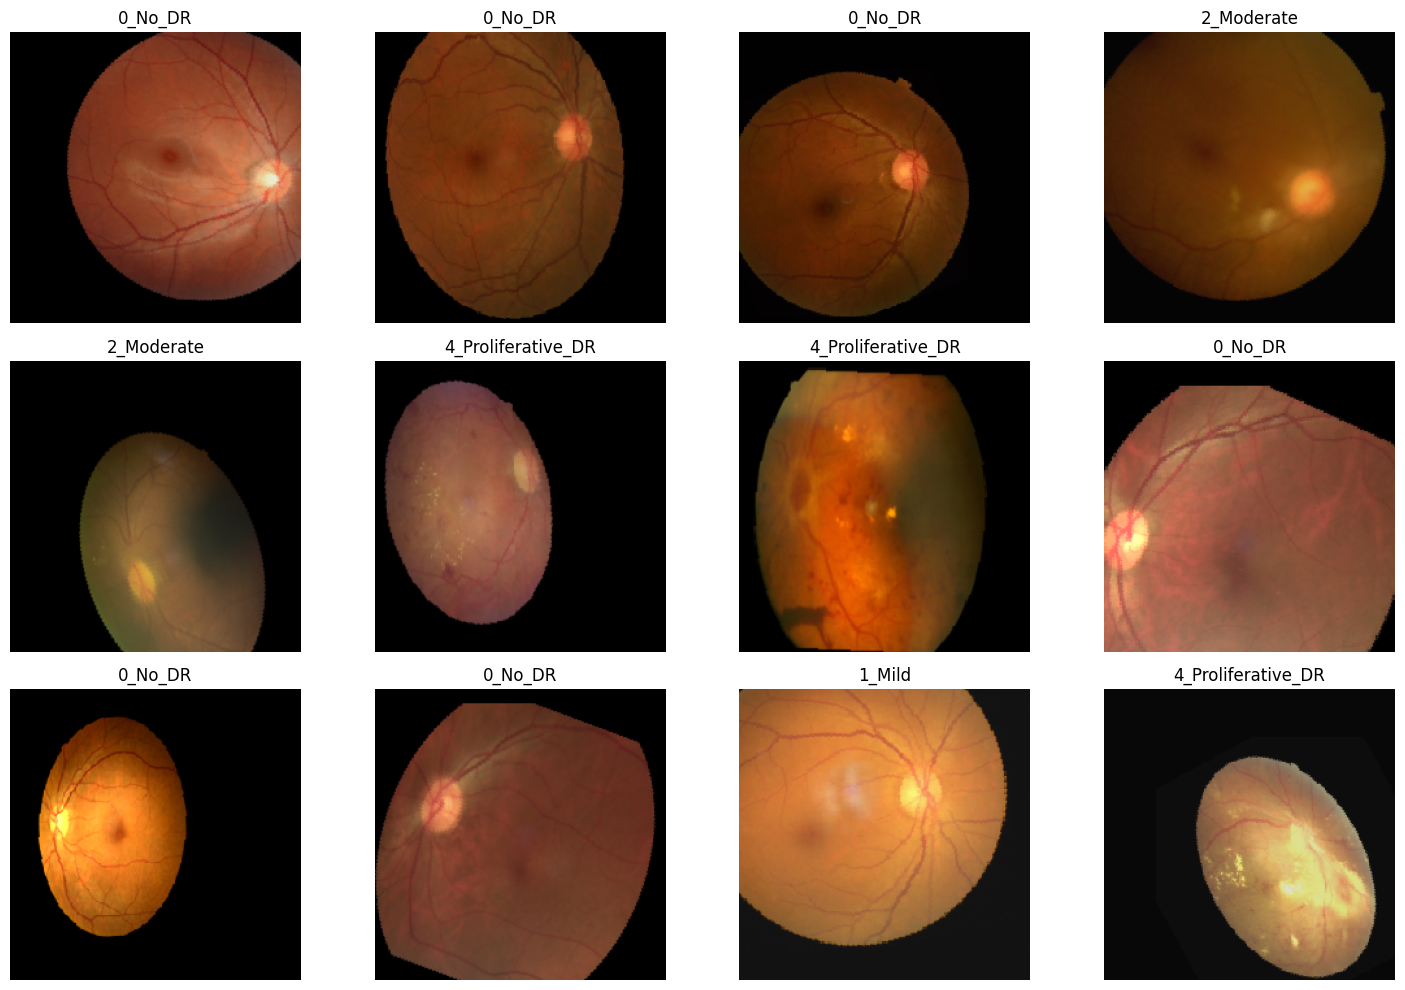

In [18]:
def denormalize(img):

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    img = (
        img * std
        + mean
    )

    return torch.clamp(
        img,
        0,
        1
    )


images, labels = next(
    iter(train_loader)
)


plt.figure(
    figsize=(15, 10)
)


for i in range(
    min(12, len(images))
):

    img = denormalize(
        images[i]
    )

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        img.permute(
            1,
            2,
            0
        )
    )

    plt.title(
        CLASS_NAMES[
            labels[i].item()
        ]
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

In [19]:
print(
    "Loading ImageNet-pretrained ResNet50..."
)


weights = (
    ResNet50_Weights.IMAGENET1K_V2
)


model = resnet50(
    weights=weights
)


# Replace ImageNet classifier
model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)


model = model.to(device)


print(
    "ResNet50 loaded successfully."
)

Loading ImageNet-pretrained ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


ResNet50 loaded successfully.


In [20]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)

print(
    "Model             :",
    MODEL_NAME
)

print(
    "Total parameters  :",
    f"{total_params:,}"
)

print(
    "Trainable params  :",
    f"{trainable_params:,}"
)

print(
    "Device            :",
    device
)

MODEL SUMMARY
Model             : ResNet50
Total parameters  : 23,518,277
Trainable params  : 23,518,277
Device            : cuda


In [21]:
criterion = nn.CrossEntropyLoss()

print(
    "Loss function:",
    criterion
)

Loss function: CrossEntropyLoss()


In [22]:
optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0005
)


In [23]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=3,

    min_lr=1e-7
)


print(
    "ReduceLROnPlateau scheduler created."
)

ReduceLROnPlateau scheduler created.


In [24]:
def calculate_basic_metrics(
    y_true,
    y_pred
):

    return {

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "precision_macro":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "recall_macro":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "f1_macro":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "precision_weighted":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "recall_weighted":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "f1_weighted":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "cohen_kappa":
            cohen_kappa_score(
                y_true,
                y_pred
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            )
    }

In [25]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_targets = []


    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )


    for images, targets in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        outputs = model(
            images
        )


        loss = criterion(
            outputs,
            targets
        )


        loss.backward()

        optimizer.step()


        running_loss += (
            loss.item()
            *
            images.size(0)
        )


        preds = outputs.argmax(
            dim=1
        )


        all_preds.extend(
            preds.detach()
            .cpu()
            .numpy()
        )

        all_targets.extend(
            targets.detach()
            .cpu()
            .numpy()
        )


    epoch_loss = (
        running_loss
        /
        len(loader.dataset)
    )


    metrics = calculate_basic_metrics(
        np.array(all_targets),
        np.array(all_preds)
    )


    return epoch_loss, metrics

In [26]:
@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_targets = []


    progress = tqdm(
        loader,
        desc="Validation",
        leave=False
    )


    for images, targets in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )


        outputs = model(
            images
        )


        loss = criterion(
            outputs,
            targets
        )


        running_loss += (
            loss.item()
            *
            images.size(0)
        )


        preds = outputs.argmax(
            dim=1
        )


        all_preds.extend(
            preds.cpu()
            .numpy()
        )

        all_targets.extend(
            targets.cpu()
            .numpy()
        )


    epoch_loss = (
        running_loss
        /
        len(loader.dataset)
    )


    metrics = calculate_basic_metrics(
        np.array(all_targets),
        np.array(all_preds)
    )


    return epoch_loss, metrics

In [27]:
RESULTS_DIR = Path(
    "/kaggle/working/resnet50_ddr_results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CHECKPOINT_PATH = (
    RESULTS_DIR
    /
    "best_resnet50_ddr.pth"
)


print(
    "Results directory:"
)

print(
    RESULTS_DIR
)

Results directory:
/kaggle/working/resnet50_ddr_results


In [28]:
history = {

    "epoch": [],

    "train_loss": [],
    "val_loss": [],

    "train_accuracy": [],
    "val_accuracy": [],

    "train_precision_macro": [],
    "val_precision_macro": [],

    "train_recall_macro": [],
    "val_recall_macro": [],

    "train_f1_macro": [],
    "val_f1_macro": [],

    "train_balanced_accuracy": [],
    "val_balanced_accuracy": [],

    "train_kappa": [],
    "val_kappa": [],

    "train_mcc": [],
    "val_mcc": [],

    "learning_rate": []
}


best_val_f1 = -np.inf

epochs_without_improvement = 0

start_time = time.time()


for epoch in range(
    1,
    EPOCHS + 1
):

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"EPOCH {epoch}/{EPOCHS}"
    )

    print(
        "=" * 80
    )


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_loss, train_metrics = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_loss, val_metrics = (
        validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )
    )


    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # Scheduler monitors validation Macro-F1
    scheduler.step(
        val_metrics["f1_macro"]
    )


    # --------------------------------------------------------
    # STORE HISTORY
    # --------------------------------------------------------

    history["epoch"].append(
        epoch
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )


    history["train_accuracy"].append(
        train_metrics["accuracy"]
    )

    history["val_accuracy"].append(
        val_metrics["accuracy"]
    )


    history["train_precision_macro"].append(
        train_metrics["precision_macro"]
    )

    history["val_precision_macro"].append(
        val_metrics["precision_macro"]
    )


    history["train_recall_macro"].append(
        train_metrics["recall_macro"]
    )

    history["val_recall_macro"].append(
        val_metrics["recall_macro"]
    )


    history["train_f1_macro"].append(
        train_metrics["f1_macro"]
    )

    history["val_f1_macro"].append(
        val_metrics["f1_macro"]
    )


    history["train_balanced_accuracy"].append(
        train_metrics["balanced_accuracy"]
    )

    history["val_balanced_accuracy"].append(
        val_metrics["balanced_accuracy"]
    )


    history["train_kappa"].append(
        train_metrics["cohen_kappa"]
    )

    history["val_kappa"].append(
        val_metrics["cohen_kappa"]
    )


    history["train_mcc"].append(
        train_metrics["mcc"]
    )

    history["val_mcc"].append(
        val_metrics["mcc"]
    )


    history["learning_rate"].append(
        current_lr
    )


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(
        f"Train Loss       : {train_loss:.4f}"
    )

    print(
        f"Val Loss         : {val_loss:.4f}"
    )

    print(
        f"Train Accuracy   : "
        f"{train_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Accuracy     : "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Train Macro-F1   : "
        f"{train_metrics['f1_macro']:.4f}"
    )

    print(
        f"Val Macro-F1     : "
        f"{val_metrics['f1_macro']:.4f}"
    )

    print(
        f"Val Balanced Acc : "
        f"{val_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Learning Rate    : "
        f"{current_lr:.8f}"
    )


    # --------------------------------------------------------
    # BEST CHECKPOINT
    # --------------------------------------------------------

    if (
        val_metrics["f1_macro"]
        >
        best_val_f1
    ):

        best_val_f1 = (
            val_metrics["f1_macro"]
        )

        epochs_without_improvement = 0


        torch.save(

            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "best_val_f1":
                    best_val_f1,

                "class_names":
                    CLASS_NAMES,

                "seed":
                    SEED
            },

            CHECKPOINT_PATH
        )


        print(
            f"✓ Best model saved "
            f"(Val Macro-F1 = "
            f"{best_val_f1:.4f})"
        )


    else:

        epochs_without_improvement += 1


        print(
            f"No improvement: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


training_time = (
    time.time()
    -
    start_time
)


print(
    "\n"
    + "=" * 80
)

print(
    "DDR RESNET50 TRAINING COMPLETE"
)

print(
    "=" * 80
)

print(
    f"Training time: "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Best validation Macro-F1: "
    f"{best_val_f1:.4f}"
)


EPOCH 1/50


Training:   0%|          | 0/622 [00:00<?, ?it/s]

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

Train Loss       : 1.0169
Val Loss         : 1.1183
Train Accuracy   : 0.5747
Val Accuracy     : 0.4581
Train Macro-F1   : 0.5677
Val Macro-F1     : 0.4411
Val Balanced Acc : 0.6104
Learning Rate    : 0.00010000
✓ Best model saved (Val Macro-F1 = 0.4411)

EPOCH 2/50


Training:   0%|          | 0/622 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

Train Loss       : 0.0384
Val Loss         : 0.8981
Train Accuracy   : 0.9867
Val Accuracy     : 0.8269
Train Macro-F1   : 0.9865
Val Macro-F1     : 0.6319
Val Balanced Acc : 0.5925
Learning Rate    : 0.00000078
No improvement: 27/100

EPOCH 50/50


Training:   0%|          | 0/622 [00:00<?, ?it/s]

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

Train Loss       : 0.0477
Val Loss         : 0.8677
Train Accuracy   : 0.9824
Val Accuracy     : 0.8285
Train Macro-F1   : 0.9822
Val Macro-F1     : 0.6332
Val Balanced Acc : 0.6008
Learning Rate    : 0.00000078
No improvement: 28/100

DDR RESNET50 TRAINING COMPLETE
Training time: 405.84 minutes
Best validation Macro-F1: 0.6656


In [29]:
history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    RESULTS_DIR /
    "training_history.csv",
    index=False
)


display(history_df)

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_precision_macro,val_precision_macro,train_recall_macro,val_recall_macro,train_f1_macro,val_f1_macro,train_balanced_accuracy,val_balanced_accuracy,train_kappa,val_kappa,train_mcc,val_mcc,learning_rate
0,1,1.016906,1.118300,0.574721,0.458132,0.565697,0.499178,0.574371,0.610424,0.567710,0.441089,0.574371,0.610424,0.468384,0.308548,0.469434,0.358232,1.000000e-04
1,2,0.773144,0.799236,0.682399,0.648953,0.681242,0.560306,0.685589,0.611016,0.681417,0.538374,0.685589,0.611016,0.603061,0.488409,0.604084,0.509966,1.000000e-04
2,3,0.644027,0.824952,0.740062,0.668277,0.737106,0.579024,0.739049,0.653171,0.736146,0.575129,0.739049,0.653171,0.675021,0.519315,0.675957,0.540787,1.000000e-04
3,4,0.568827,0.766693,0.771863,0.685185,0.770665,0.576677,0.771986,0.647614,0.769458,0.568521,0.771986,0.647614,0.714823,0.536538,0.715751,0.554527,1.000000e-04
4,5,0.516847,0.854299,0.794707,0.671498,0.793840,0.563553,0.795160,0.651269,0.793206,0.557886,0.795160,0.651269,0.743392,0.518705,0.744085,0.533260,1.000000e-04
5,6,0.444727,0.663428,0.826004,0.759259,0.824872,0.583725,0.824957,0.632855,0.823850,0.600733,0.824957,0.632855,0.782470,0.620402,0.782990,0.622838,1.000000e-04
6,7,0.406788,0.737086,0.846734,0.742351,0.845192,0.600712,0.844906,0.680891,0.844165,0.608655,0.844906,0.680891,0.808358,0.597325,0.808800,0.605184,1.000000e-04
7,8,0.387159,0.708065,0.852672,0.752818,0.851836,0.601847,0.851471,0.646989,0.850540,0.604338,0.851471,0.646989,0.815761,0.608788,0.816312,0.614566,1.000000e-04
8,9,0.373711,0.703847,0.855490,0.769726,0.854872,0.654792,0.856365,0.666719,0.855083,0.645061,0.856365,0.666719,0.819383,0.636070,0.819661,0.641589,1.000000e-04
9,10,0.334739,0.716845,0.868371,0.770531,0.866974,0.624826,0.867244,0.656376,0.866480,0.625526,0.867244,0.656376,0.835435,0.639282,0.835757,0.645828,1.000000e-04


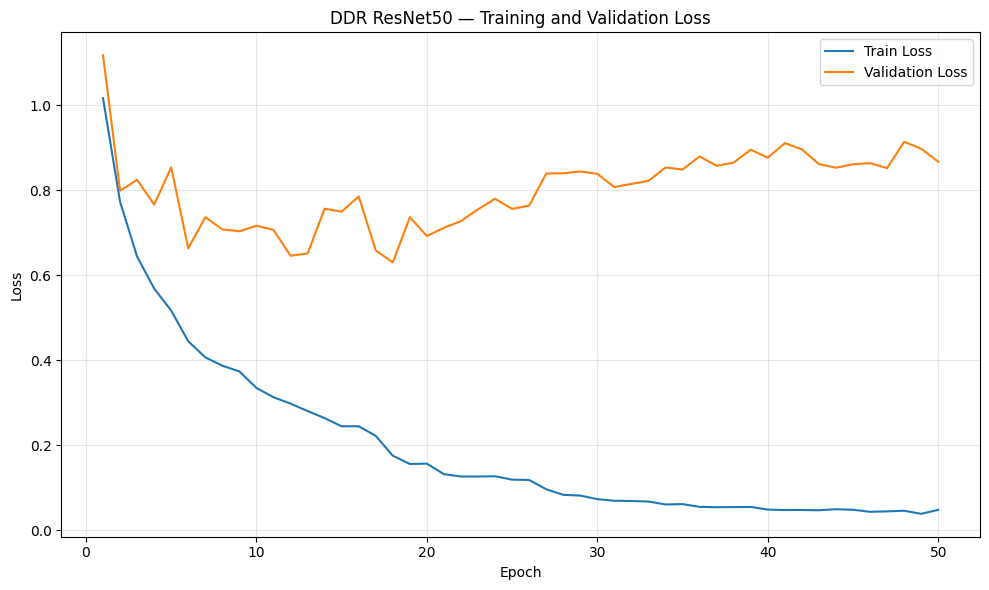

In [30]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DDR ResNet50 — Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "loss_curve.png",
    dpi=300
)

plt.show()

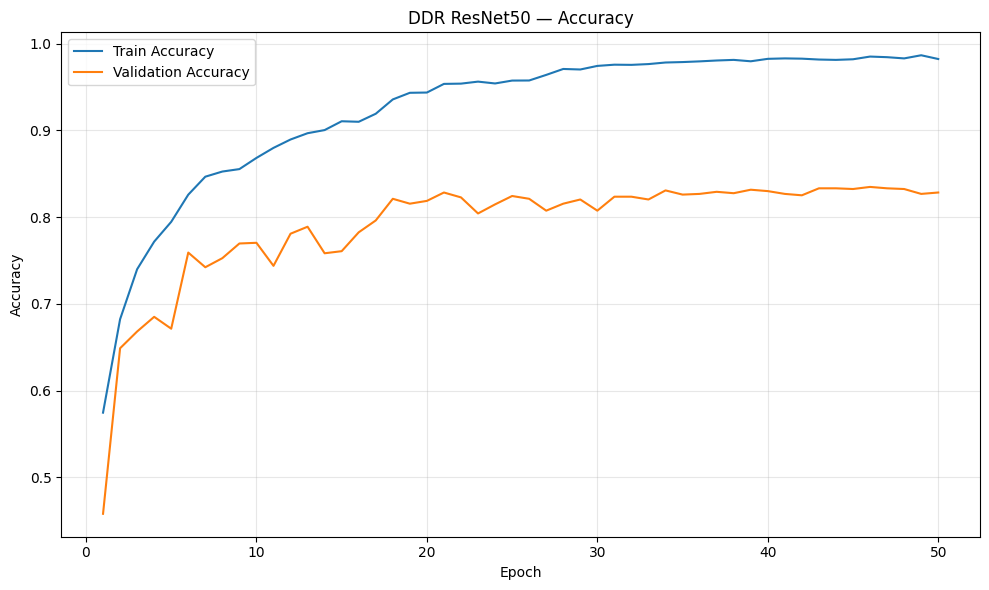

In [31]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "DDR ResNet50 — Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "accuracy_curve.png",
    dpi=300
)

plt.show()

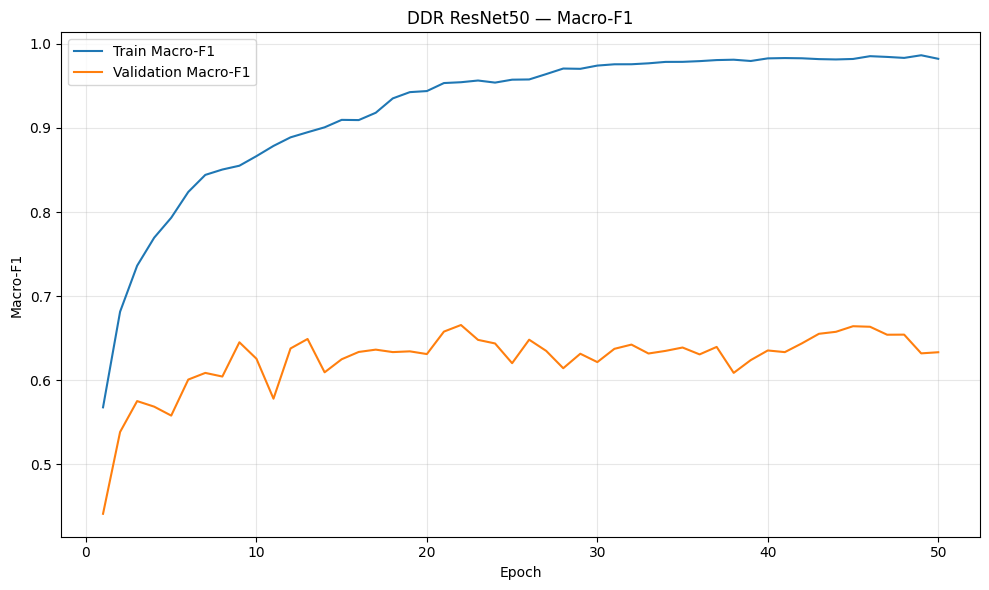

In [32]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_f1_macro"],
    label="Train Macro-F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1_macro"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")

plt.title(
    "DDR ResNet50 — Macro-F1"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "macro_f1_curve.png",
    dpi=300
)

plt.show()

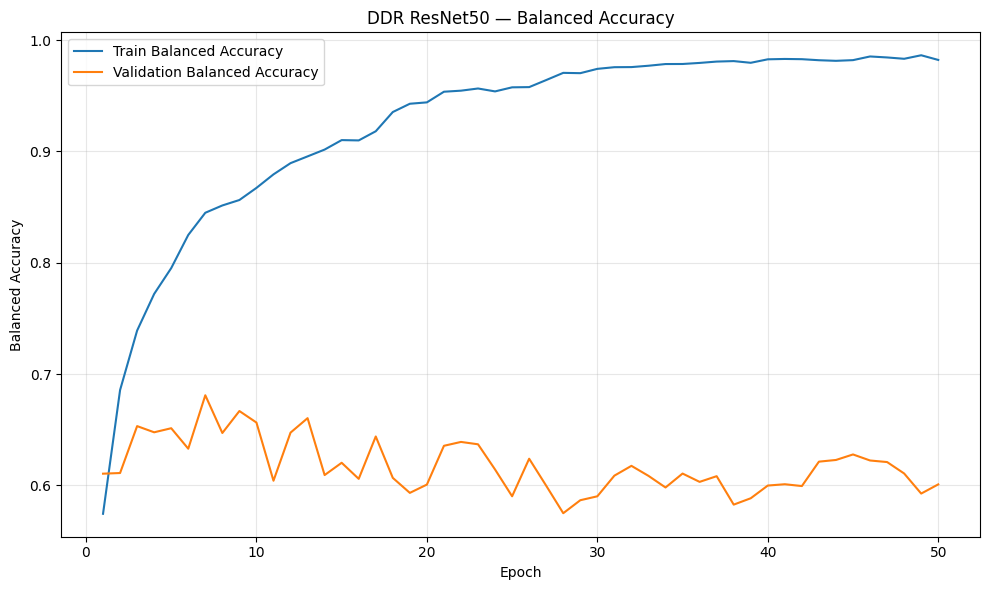

In [33]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_balanced_accuracy"],
    label="Train Balanced Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_balanced_accuracy"],
    label="Validation Balanced Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")

plt.title(
    "DDR ResNet50 — Balanced Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "balanced_accuracy_curve.png",
    dpi=300
)

plt.show()

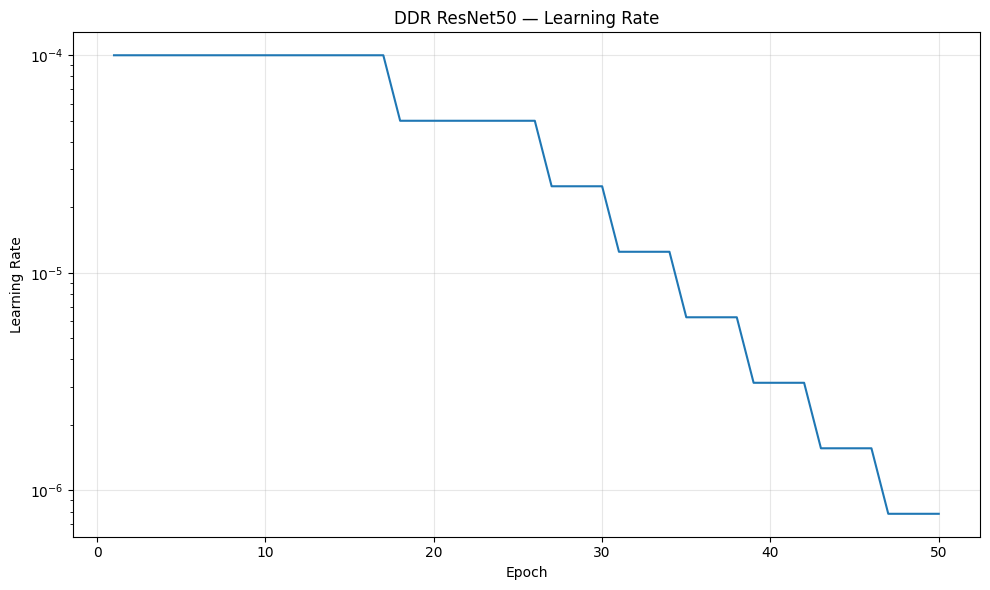

In [34]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["learning_rate"]
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title(
    "DDR ResNet50 — Learning Rate"
)

plt.yscale("log")

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "learning_rate_curve.png",
    dpi=300
)

plt.show()

In [35]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model = model.to(device)


print(
    "Best checkpoint loaded."
)

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Macro-F1:",
    checkpoint["best_val_f1"]
)

Best checkpoint loaded.
Best epoch: 22
Best validation Macro-F1: 0.6656183227720919


In [36]:
@torch.no_grad()
def get_predictions(
    model,
    loader,
    device
):

    model.eval()

    all_targets = []
    all_preds = []
    all_probs = []


    for images, targets in tqdm(
        loader,
        desc="Testing"
    ):

        images = images.to(
            device,
            non_blocking=True
        )


        outputs = model(
            images
        )


        probs = torch.softmax(
            outputs,
            dim=1
        )


        preds = torch.argmax(
            probs,
            dim=1
        )


        all_targets.extend(
            targets.numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )


    return (

        np.array(all_targets),

        np.array(all_preds),

        np.array(all_probs)

    )

In [37]:
y_true, y_pred, y_prob = get_predictions(
    model,
    test_loader,
    device
)


print(
    "Test samples:",
    len(y_true)
)

print(
    "Probability shape:",
    y_prob.shape
)

Testing:   0%|          | 0/78 [00:00<?, ?it/s]

Test samples: 1243
Probability shape: (1243, 5)


In [38]:
test_metrics = calculate_basic_metrics(
    y_true,
    y_pred
)


metrics_df = pd.DataFrame(
    [test_metrics]
)


display(metrics_df)

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,balanced_accuracy,cohen_kappa,mcc
0,0.827031,0.649269,0.606208,0.625248,0.819561,0.827031,0.822173,0.606208,0.713398,0.714378


In [39]:
report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES,

    output_dict=True,

    zero_division=0
)


classification_df = pd.DataFrame(
    report
).T


display(
    classification_df
)


classification_df.to_csv(
    RESULTS_DIR /
    "classification_report.csv"
)

,precision,recall,f1-score,support
0_No_DR,0.873860,0.931929,0.901961,617.000000
1_Mild,0.254902,0.206349,0.228070,63.000000
2_Moderate,0.826087,0.805804,0.815819,448.000000
3_Severe,0.368421,0.304348,0.333333,23.000000
4_Proliferative_DR,0.923077,0.782609,0.847059,92.000000
accuracy,0.827031,0.827031,0.827031,0.827031
macro avg,0.649269,0.606208,0.625248,1243.000000
weighted avg,0.819561,0.827031,0.822173,1243.000000


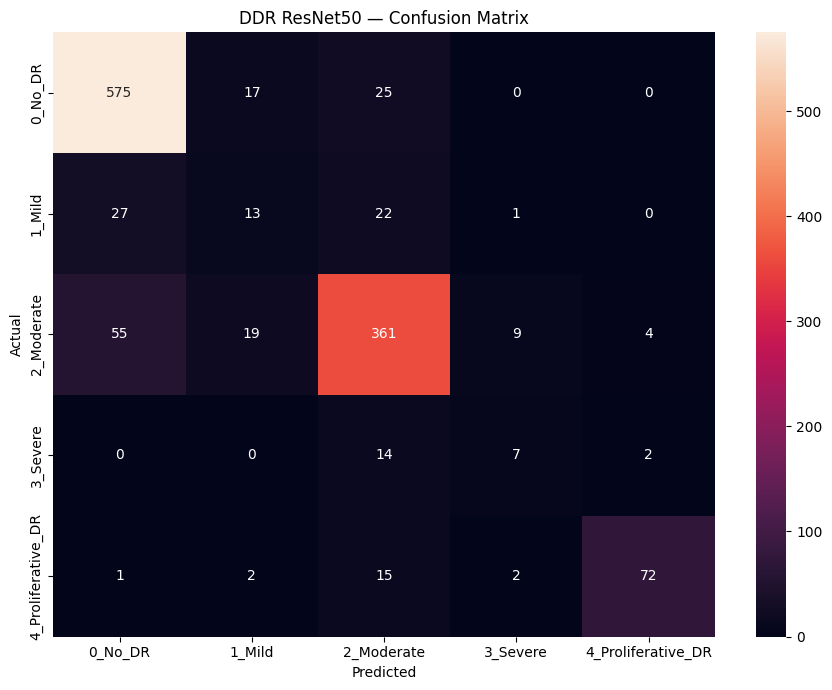

In [40]:
cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(
    figsize=(9, 7)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "DDR ResNet50 — Confusion Matrix"
)


plt.tight_layout()


plt.savefig(
    RESULTS_DIR /
    "confusion_matrix.png",
    dpi=300
)


plt.show()

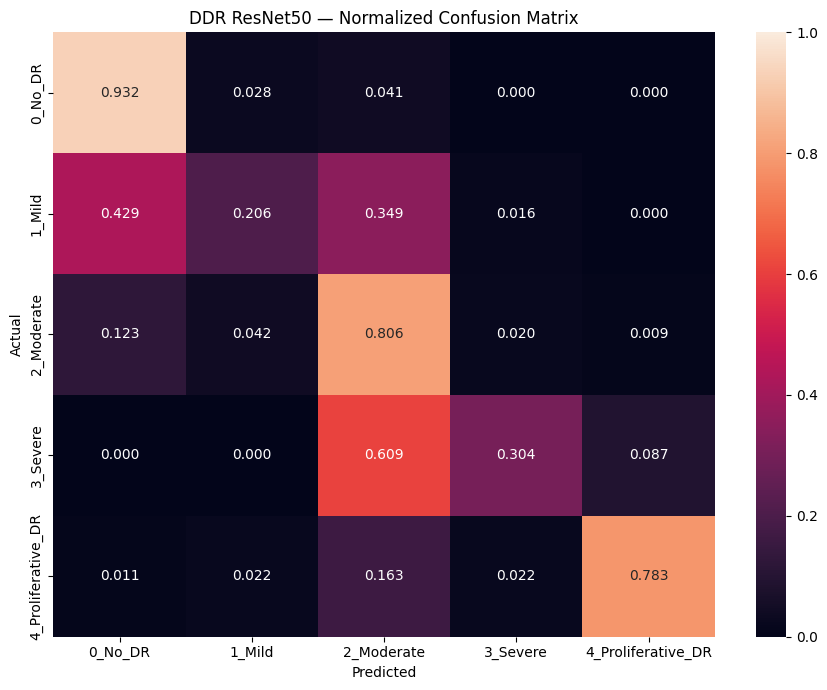

In [41]:
cm_normalized = confusion_matrix(

    y_true,

    y_pred,

    normalize="true"
)


plt.figure(
    figsize=(9, 7)
)


sns.heatmap(

    cm_normalized,

    annot=True,

    fmt=".3f",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES,

    vmin=0,

    vmax=1
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "DDR ResNet50 — Normalized Confusion Matrix"
)


plt.tight_layout()


plt.savefig(
    RESULTS_DIR /
    "normalized_confusion_matrix.png",
    dpi=300
)


plt.show()

In [42]:
per_class_results = []


for i, cls in enumerate(
    CLASS_NAMES
):

    TP = cm[i, i]

    FN = (
        cm[i, :].sum()
        -
        TP
    )

    FP = (
        cm[:, i].sum()
        -
        TP
    )

    TN = (
        cm.sum()
        -
        (
            TP
            +
            FN
            +
            FP
        )
    )


    sensitivity = (

        TP /
        (TP + FN)

        if
        (TP + FN) > 0

        else 0
    )


    specificity = (

        TN /
        (TN + FP)

        if
        (TN + FP) > 0

        else 0
    )


    precision = precision_score(

        y_true,

        y_pred,

        labels=[i],

        average="macro",

        zero_division=0
    )


    recall = recall_score(

        y_true,

        y_pred,

        labels=[i],

        average="macro",

        zero_division=0
    )


    f1 = f1_score(

        y_true,

        y_pred,

        labels=[i],

        average="macro",

        zero_division=0
    )


    per_class_results.append({

        "Class": cls,

        "TP": TP,

        "TN": TN,

        "FP": FP,

        "FN": FN,

        "Sensitivity": sensitivity,

        "Specificity": specificity,

        "Precision": precision,

        "Recall": recall,

        "F1": f1
    })


per_class_df = pd.DataFrame(
    per_class_results
)


display(
    per_class_df
)


per_class_df.to_csv(
    RESULTS_DIR /
    "per_class_metrics.csv",
    index=False
)

,Class,TP,TN,FP,FN,Sensitivity,Specificity,Precision,Recall,F1
0,0_No_DR,575,543,83,42,0.931929,0.867412,0.873860,0.931929,0.901961
1,1_Mild,13,1142,38,50,0.206349,0.967797,0.254902,0.206349,0.228070
2,2_Moderate,361,719,76,87,0.805804,0.904403,0.826087,0.805804,0.815819
3,3_Severe,7,1208,12,16,0.304348,0.990164,0.368421,0.304348,0.333333
4,4_Proliferative_DR,72,1145,6,20,0.782609,0.994787,0.923077,0.782609,0.847059


In [43]:
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(
        NUM_CLASSES
    )
)


roc_auc_per_class = {}


for i, cls in enumerate(
    CLASS_NAMES
):

    roc_auc_per_class[cls] = (
        roc_auc_score(

            y_true_bin[:, i],

            y_prob[:, i]
        )
    )


roc_auc_macro = roc_auc_score(

    y_true_bin,

    y_prob,

    average="macro",

    multi_class="ovr"
)


roc_auc_weighted = roc_auc_score(

    y_true_bin,

    y_prob,

    average="weighted",

    multi_class="ovr"
)


print(
    "ROC-AUC Macro   :",
    roc_auc_macro
)

print(
    "ROC-AUC Weighted:",
    roc_auc_weighted
)


print(
    "\nPer-class ROC-AUC:"
)


for cls, score in (
    roc_auc_per_class.items()
):

    print(
        f"{cls:<22}: "
        f"{score:.4f}"
    )

ROC-AUC Macro   : 0.9030089472641141
ROC-AUC Weighted: 0.9382805828087227

Per-class ROC-AUC:
0_No_DR               : 0.9637
1_Mild                : 0.7802
2_Moderate            : 0.9203
3_Severe              : 0.8704
4_Proliferative_DR    : 0.9804


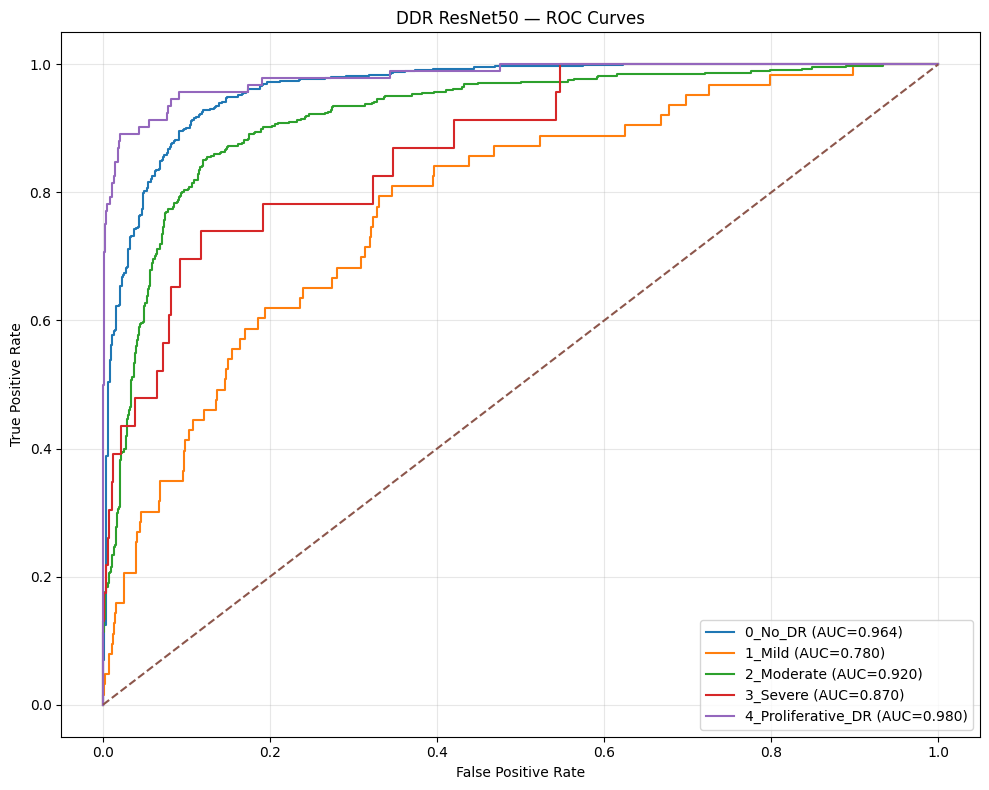

In [44]:
plt.figure(
    figsize=(10, 8)
)


for i, cls in enumerate(
    CLASS_NAMES
):

    fpr, tpr, _ = roc_curve(

        y_true_bin[:, i],

        y_prob[:, i]
    )


    roc_auc = auc(
        fpr,
        tpr
    )


    plt.plot(

        fpr,

        tpr,

        label=(
            f"{cls} "
            f"(AUC={roc_auc:.3f})"
        )
    )


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "DDR ResNet50 — ROC Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    RESULTS_DIR /
    "roc_curves.png",
    dpi=300
)


plt.show()

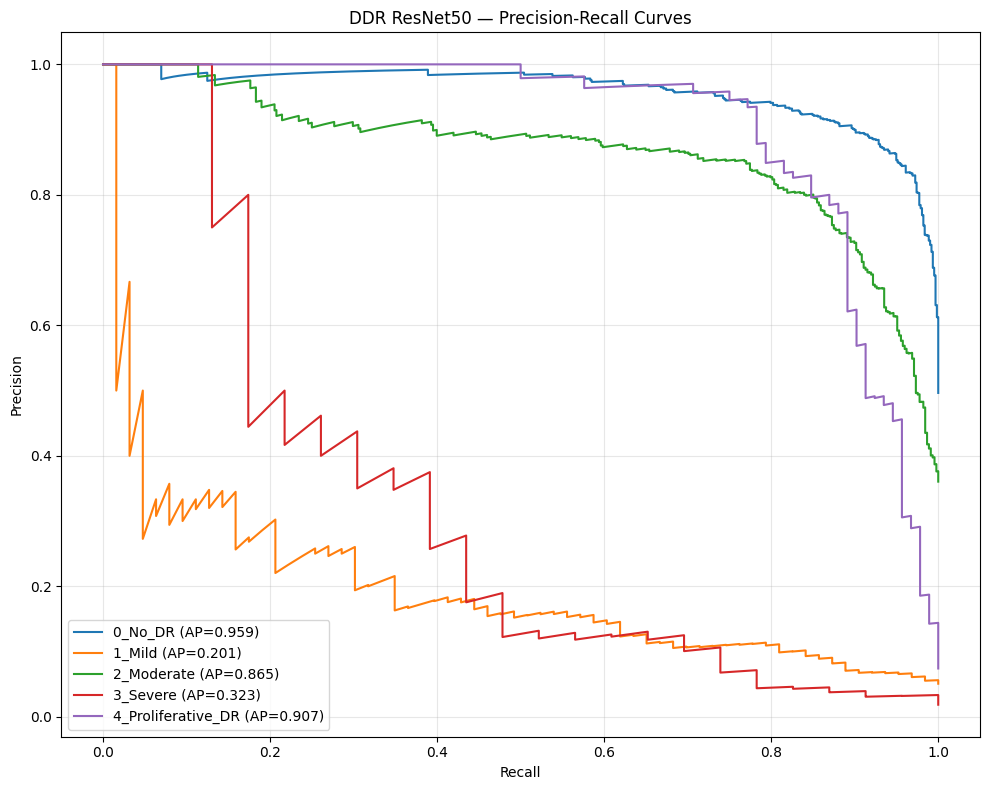

In [45]:
plt.figure(
    figsize=(10, 8)
)


pr_auc_per_class = {}


for i, cls in enumerate(
    CLASS_NAMES
):

    precision, recall, _ = (
        precision_recall_curve(

            y_true_bin[:, i],

            y_prob[:, i]
        )
    )


    ap = average_precision_score(

        y_true_bin[:, i],

        y_prob[:, i]
    )


    pr_auc_per_class[cls] = ap


    plt.plot(

        recall,

        precision,

        label=(
            f"{cls} "
            f"(AP={ap:.3f})"
        )
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "DDR ResNet50 — Precision-Recall Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    RESULTS_DIR /
    "precision_recall_curves.png",
    dpi=300
)


plt.show()

In [46]:
pr_auc_macro = np.mean(
    list(
        pr_auc_per_class.values()
    )
)


print(
    "PR-AUC Macro:",
    pr_auc_macro
)


for cls, score in (
    pr_auc_per_class.items()
):

    print(
        f"{cls:<22}: "
        f"{score:.4f}"
    )

PR-AUC Macro: 0.6510740439173313
0_No_DR               : 0.9589
1_Mild                : 0.2010
2_Moderate            : 0.8655
3_Severe              : 0.3234
4_Proliferative_DR    : 0.9066


In [47]:
test_log_loss = log_loss(

    y_true,

    y_prob,

    labels=np.arange(
        NUM_CLASSES
    )
)


print(
    f"DDR ResNet50 Test Log Loss: "
    f"{test_log_loss:.6f}"
)

DDR ResNet50 Test Log Loss: 0.777359


In [48]:
brier_scores = {}


for i, cls in enumerate(
    CLASS_NAMES
):

    brier_scores[cls] = (
        brier_score_loss(

            y_true_bin[:, i],

            y_prob[:, i]
        )
    )


brier_df = pd.DataFrame({

    "Class":
        list(
            brier_scores.keys()
        ),

    "Brier Score":
        list(
            brier_scores.values()
        )
})


display(
    brier_df
)


brier_df.to_csv(

    RESULTS_DIR /
    "brier_scores.csv",

    index=False
)

,Class,Brier Score
0,0_No_DR,0.076261
1,1_Mild,0.060534
2,2_Moderate,0.107558
3,3_Severe,0.020279
4,4_Proliferative_DR,0.018673


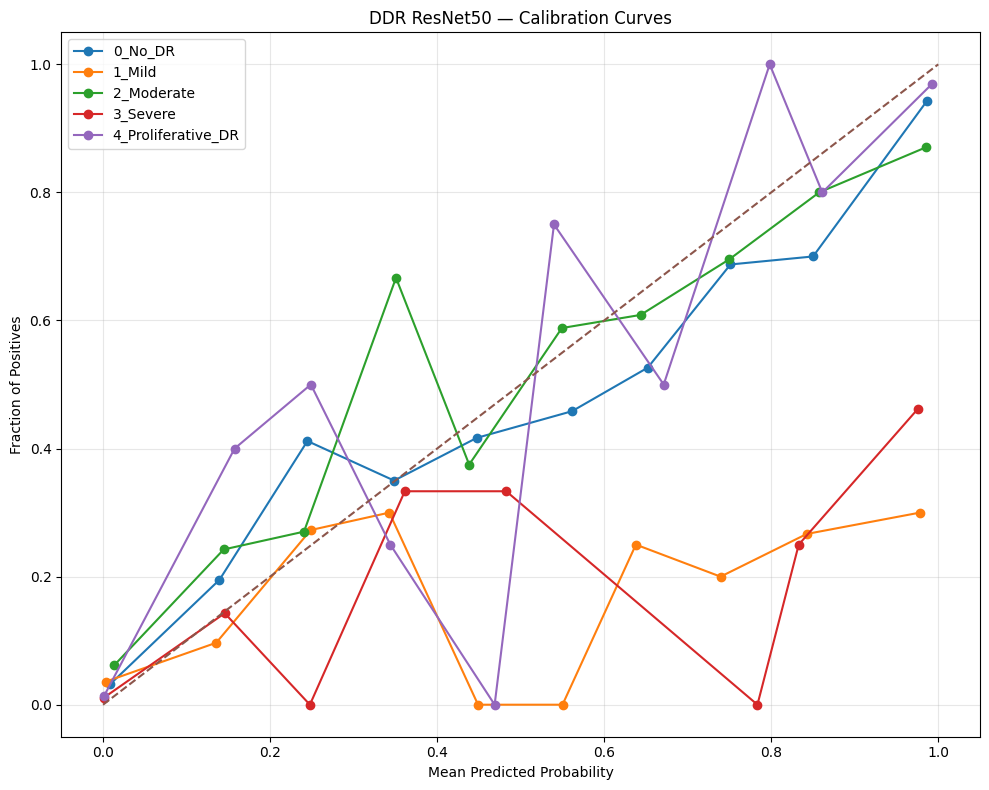

In [49]:
plt.figure(
    figsize=(10, 8)
)


for i, cls in enumerate(
    CLASS_NAMES
):

    prob_true, prob_pred = (
        calibration_curve(

            y_true_bin[:, i],

            y_prob[:, i],

            n_bins=10,

            strategy="uniform"
        )
    )


    plt.plot(

        prob_pred,

        prob_true,

        marker="o",

        label=cls
    )


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"
)


plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Fraction of Positives"
)

plt.title(
    "DDR ResNet50 — Calibration Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(

    RESULTS_DIR /
    "calibration_curves.png",

    dpi=300
)


plt.show()

In [50]:
confidence = np.max(
    y_prob,
    axis=1
)


correct = (
    y_true == y_pred
)


print(
    "Mean confidence:",
    confidence.mean()
)


print(
    "Correct prediction confidence:",
    confidence[
        correct
    ].mean()
)


print(
    "Incorrect prediction confidence:",
    confidence[
        ~correct
    ].mean()
)

Mean confidence: 0.92451084
Correct prediction confidence: 0.9456932
Incorrect prediction confidence: 0.8232304


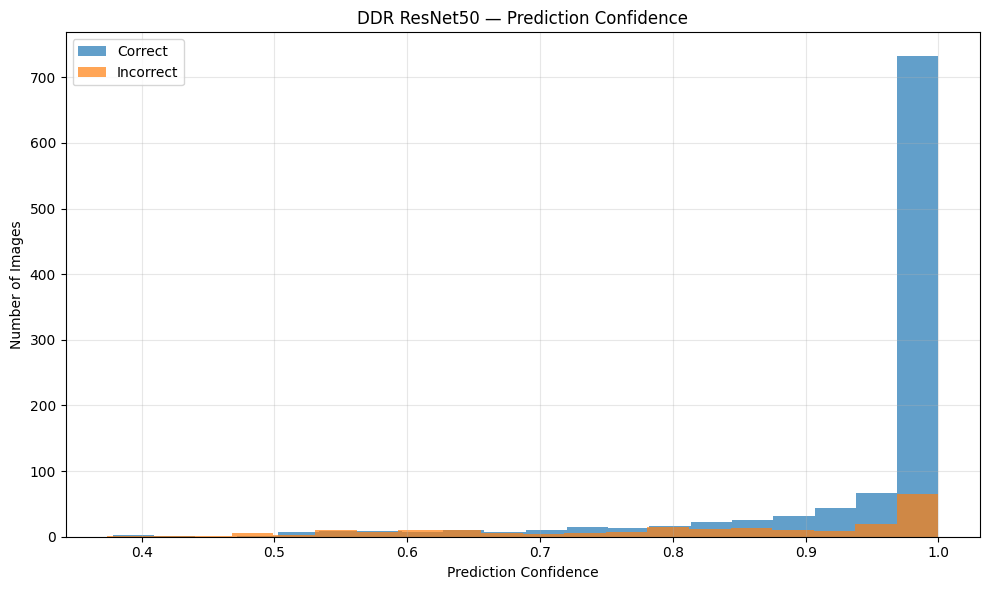

In [51]:
plt.figure(
    figsize=(10, 6)
)


plt.hist(

    confidence[correct],

    bins=20,

    alpha=0.7,

    label="Correct"
)


plt.hist(

    confidence[~correct],

    bins=20,

    alpha=0.7,

    label="Incorrect"
)


plt.xlabel(
    "Prediction Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "DDR ResNet50 — Prediction Confidence"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(

    RESULTS_DIR /
    "confidence_distribution.png",

    dpi=300
)


plt.show()

In [52]:
test_paths = [
    path
    for path, _
    in test_dataset.samples
]


prediction_records = []


for i in range(
    len(y_true)
):

    record = {

        "image_path":
            test_paths[i],

        "true_label":
            CLASS_NAMES[
                y_true[i]
            ],

        "predicted_label":
            CLASS_NAMES[
                y_pred[i]
            ],

        "confidence":
            confidence[i],

        "correct":
            bool(
                correct[i]
            )
    }


    for j, cls in enumerate(
        CLASS_NAMES
    ):

        record[
            f"prob_{cls}"
        ] = y_prob[i, j]


    prediction_records.append(
        record
    )


predictions_df = pd.DataFrame(
    prediction_records
)


predictions_df.to_csv(

    RESULTS_DIR /
    "test_predictions.csv",

    index=False
)


display(
    predictions_df.head()
)

,image_path,true_label,predicted_label,confidence,correct,prob_0_No_DR,prob_1_Mild,prob_2_Moderate,prob_3_Severe,prob_4_Proliferative_DR
0,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,0_No_DR,0.940651,True,0.940651,0.000096,0.059200,5.290380e-05,2.334923e-07
1,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,0_No_DR,0.972479,True,0.972479,0.000582,0.026938,2.358875e-07,8.102306e-09
2,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,0_No_DR,0.977480,True,0.977480,0.001046,0.021472,1.123553e-06,6.473248e-07
3,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,0_No_DR,0.995926,True,0.995926,0.003154,0.000919,1.322614e-06,1.804296e-08
4,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,0_No_DR,0.947890,True,0.947890,0.027324,0.024639,1.230149e-04,2.378671e-05


In [53]:
misclassified_df = (
    predictions_df[
        ~predictions_df["correct"]
    ]
    .copy()
)


print(
    "Total test images:",
    len(predictions_df)
)

print(
    "Misclassified:",
    len(misclassified_df)
)

print(
    "Misclassification rate:",
    len(misclassified_df)
    /
    len(predictions_df)
)


misclassified_df.to_csv(

    RESULTS_DIR /
    "misclassified_images.csv",

    index=False
)


display(
    misclassified_df.head(20)
)

Total test images: 1243
Misclassified: 215
Misclassification rate: 0.17296862429605792


,image_path,true_label,predicted_label,confidence,correct,prob_0_No_DR,prob_1_Mild,prob_2_Moderate,prob_3_Severe,prob_4_Proliferative_DR
7,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,1_Mild,0.811369,False,0.150650,8.113687e-01,0.037980,2.661363e-07,4.346000e-07
10,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,2_Moderate,0.789679,False,0.209872,4.356152e-04,0.789679,2.006750e-07,1.297615e-05
31,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,2_Moderate,0.638861,False,0.359843,1.208712e-03,0.638861,4.753374e-05,4.015520e-05
34,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,2_Moderate,0.610299,False,0.353768,3.592606e-02,0.610299,3.014926e-08,6.847491e-06
42,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,2_Moderate,0.952358,False,0.047636,5.759463e-07,0.952358,9.409258e-08,4.597876e-06
43,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,1_Mild,0.631120,False,0.360126,6.311203e-01,0.008754,7.368918e-10,2.415342e-08
65,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,1_Mild,0.826034,False,0.165954,8.260341e-01,0.008010,3.356999e-07,2.017718e-06
86,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,2_Moderate,0.960028,False,0.034772,5.140952e-05,0.960028,4.318744e-07,5.148655e-03
106,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,2_Moderate,0.731408,False,0.257425,1.116119e-02,0.731408,6.789646e-09,5.631668e-06
125,/kaggle/input/datasets/samjohnstonc/ddr-prepar...,0_No_DR,1_Mild,0.736630,False,0.173587,7.366305e-01,0.089782,2.925089e-08,4.717429e-07


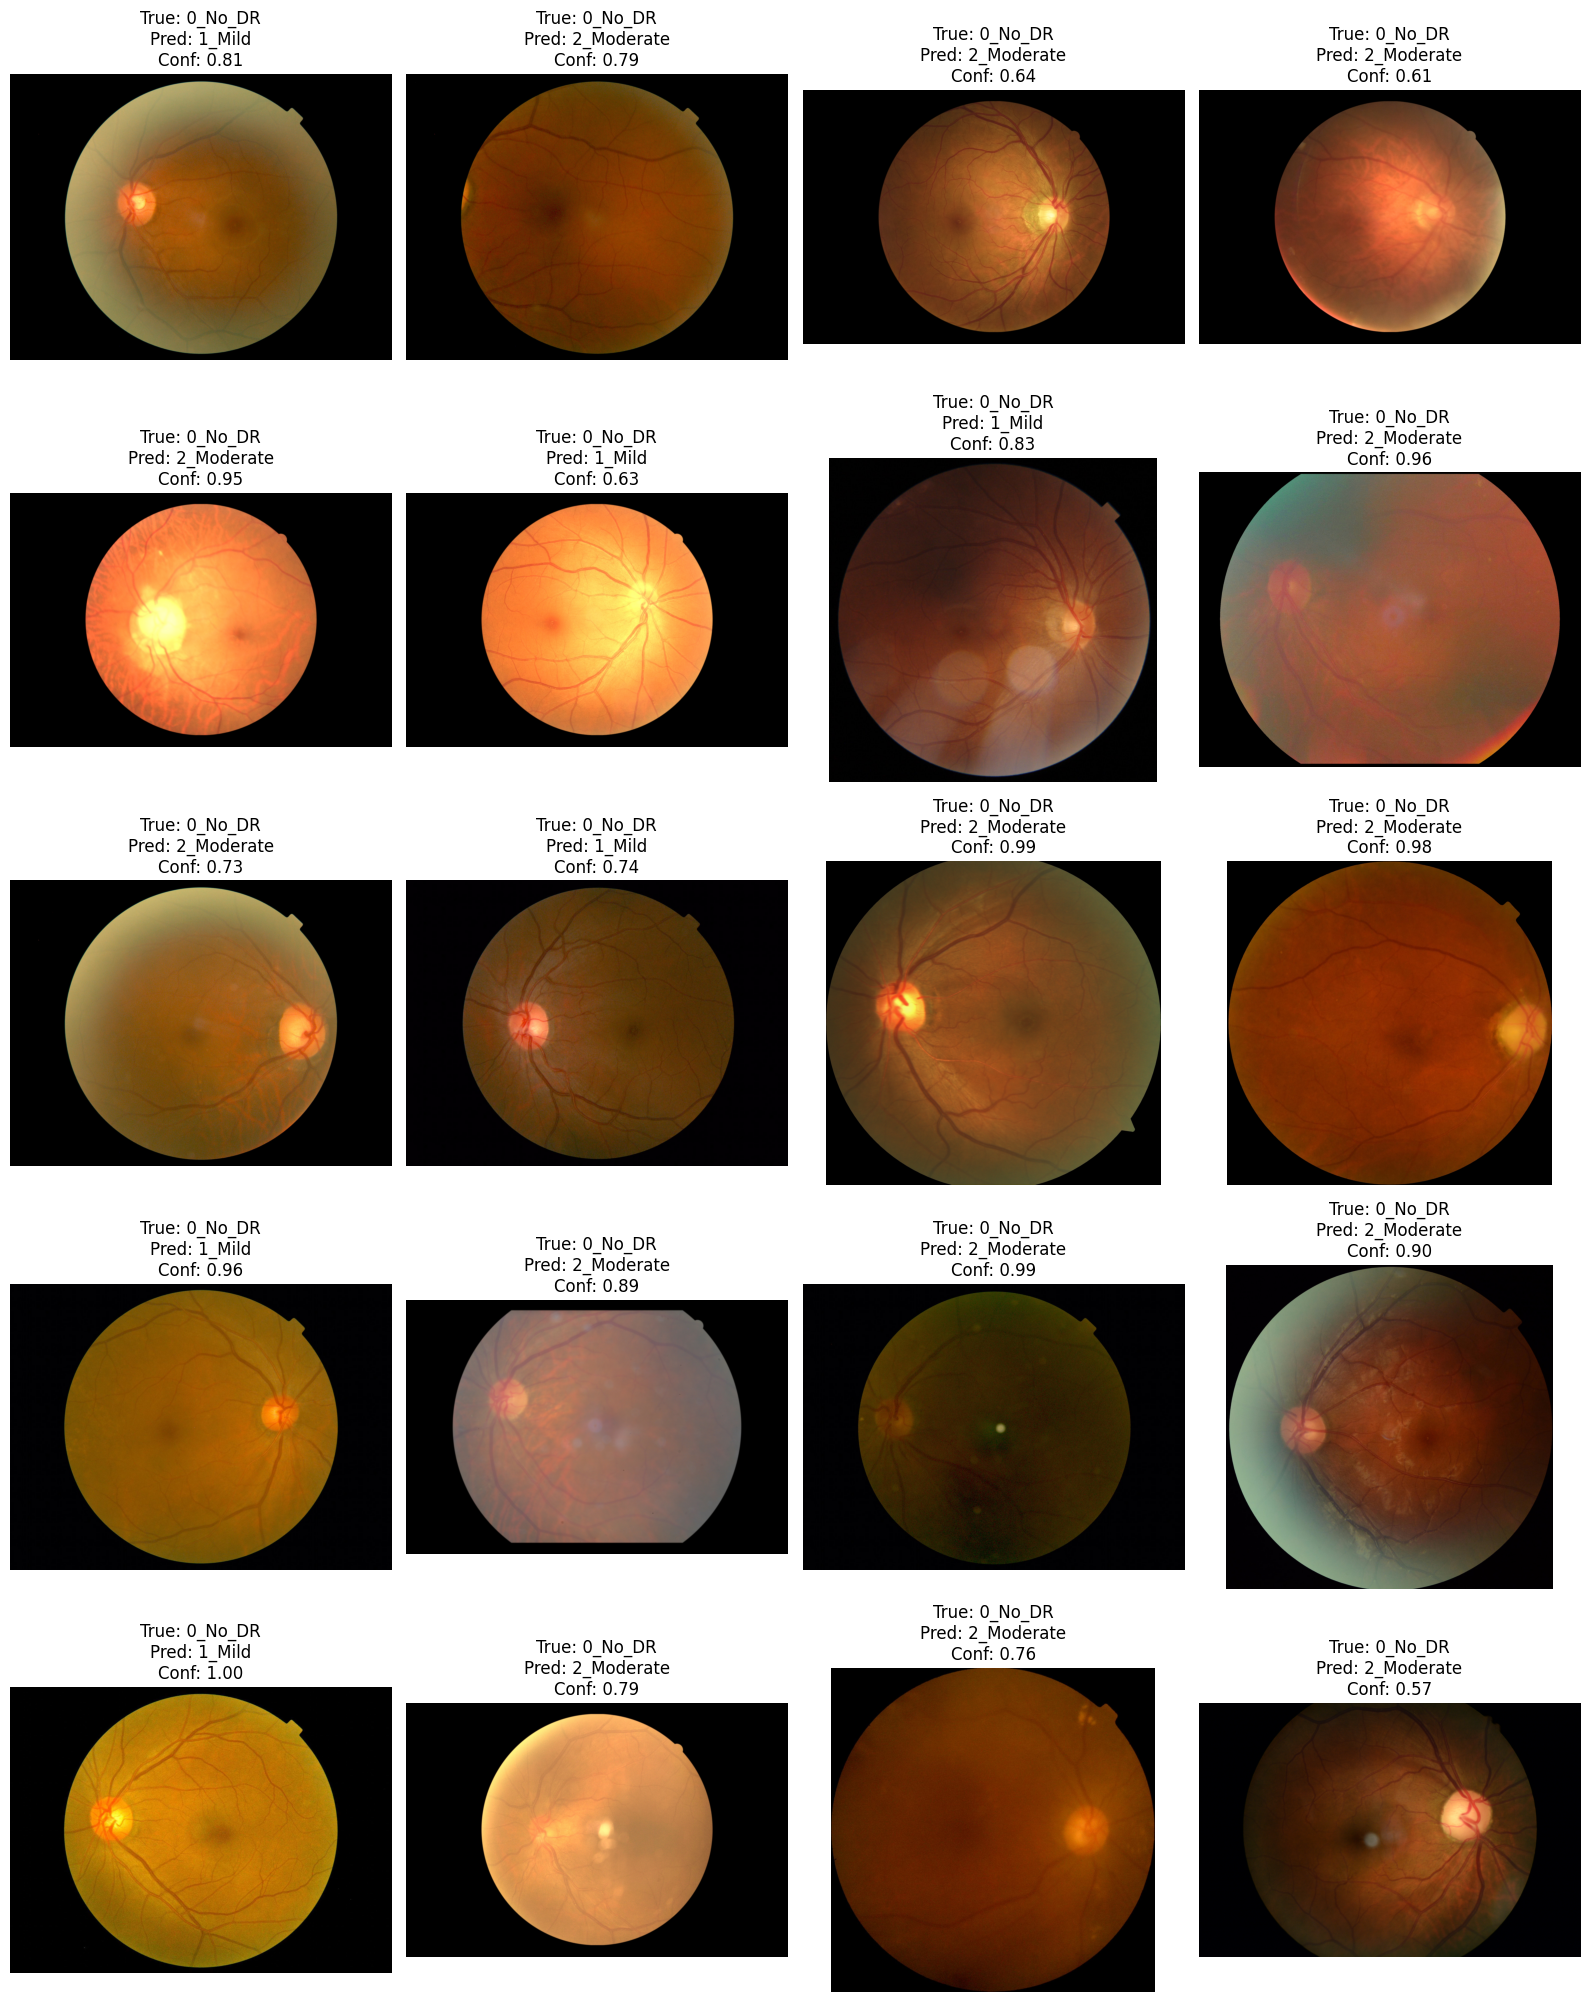

In [54]:
num_images = min(
    20,
    len(misclassified_df)
)


plt.figure(
    figsize=(16, 20)
)


for i in range(
    num_images
):

    row = (
        misclassified_df
        .iloc[i]
    )


    image = Image.open(
        row["image_path"]
    ).convert("RGB")


    plt.subplot(
        5,
        4,
        i + 1
    )


    plt.imshow(
        image
    )


    plt.title(

        f"True: "
        f"{row['true_label']}\n"

        f"Pred: "
        f"{row['predicted_label']}\n"

        f"Conf: "
        f"{row['confidence']:.2f}"
    )


    plt.axis("off")


plt.tight_layout()


plt.savefig(

    RESULTS_DIR /
    "misclassified_examples.png",

    dpi=300
)


plt.show()

In [55]:
def bootstrap_metric_ci(

    y_true,

    y_pred,

    metric_func,

    n_bootstrap=2000,

    seed=42
):

    rng = np.random.default_rng(
        seed
    )


    n = len(
        y_true
    )


    scores = []


    for _ in tqdm(

        range(n_bootstrap),

        desc="Bootstrap"
    ):

        indices = rng.integers(

            0,

            n,

            n
        )


        yt = y_true[
            indices
        ]

        yp = y_pred[
            indices
        ]


        try:

            score = metric_func(
                yt,
                yp
            )

            scores.append(
                score
            )

        except:

            continue


    scores = np.array(
        scores
    )


    lower = np.percentile(
        scores,
        2.5
    )

    upper = np.percentile(
        scores,
        97.5
    )


    return (

        np.mean(scores),

        lower,

        upper
    )

In [56]:
bootstrap_results = {}


metrics_to_bootstrap = {

    "Accuracy":

        lambda yt, yp:
        accuracy_score(
            yt,
            yp
        ),


    "Macro Precision":

        lambda yt, yp:
        precision_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        ),


    "Macro Recall":

        lambda yt, yp:
        recall_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        ),


    "Macro F1":

        lambda yt, yp:
        f1_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        ),


    "Balanced Accuracy":

        lambda yt, yp:
        balanced_accuracy_score(
            yt,
            yp
        ),


    "Cohen Kappa":

        lambda yt, yp:
        cohen_kappa_score(
            yt,
            yp
        ),


    "MCC":

        lambda yt, yp:
        matthews_corrcoef(
            yt,
            yp
        )
}


for name, func in (
    metrics_to_bootstrap.items()
):

    mean_score, lower, upper = (
        bootstrap_metric_ci(

            y_true,

            y_pred,

            func,

            n_bootstrap=2000,

            seed=SEED
        )
    )


    bootstrap_results[name] = {

        "Mean":
            mean_score,

        "CI_lower":
            lower,

        "CI_upper":
            upper
    }


bootstrap_df = pd.DataFrame(
    bootstrap_results
).T


display(
    bootstrap_df
)

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,Mean,CI_lower,CI_upper
Accuracy,0.826933,0.806919,0.847949
Macro Precision,0.648970,0.596791,0.703816
Macro Recall,0.605406,0.560364,0.653841
Macro F1,0.623077,0.576674,0.668820
Balanced Accuracy,0.605406,0.560364,0.653841
Cohen Kappa,0.713013,0.680909,0.745734
MCC,0.714188,0.682022,0.746553


In [57]:
bootstrap_df.to_csv(

    RESULTS_DIR /
    "bootstrap_95CI.csv"
)


print(
    "Bootstrap results saved."
)

Bootstrap results saved.


In [58]:
final_metrics = {

    "Model":
        MODEL_NAME,

    "Dataset":
        DATASET_NAME,

    "Test Samples":
        len(y_true),

    "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

    "Macro Precision":
        precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

    "Macro Recall":
        recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

    "Macro F1":
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

    "Weighted Precision":
        precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

    "Weighted Recall":
        recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

    "Weighted F1":
        f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_true,
            y_pred
        ),

    "Cohen Kappa":
        cohen_kappa_score(
            y_true,
            y_pred
        ),

    "MCC":
        matthews_corrcoef(
            y_true,
            y_pred
        ),

    "ROC-AUC Macro":
        roc_auc_macro,

    "ROC-AUC Weighted":
        roc_auc_weighted,

    "PR-AUC Macro":
        pr_auc_macro,

    "Log Loss":
        test_log_loss,

    "Best Val Macro F1":
        best_val_f1
}


final_metrics_df = pd.DataFrame(
    [final_metrics]
)


display(
    final_metrics_df.T
)

,0
Model,ResNet50
Dataset,DDR
Test Samples,1243
Accuracy,0.827031
Macro Precision,0.649269
Macro Recall,0.606208
Macro F1,0.625248
Weighted Precision,0.819561
Weighted Recall,0.827031
Weighted F1,0.822173


In [59]:
final_metrics_df.to_csv(

    RESULTS_DIR /
    "final_metrics.csv",

    index=False
)


with open(

    RESULTS_DIR /
    "final_metrics.json",

    "w"

) as f:

    json.dump(

        final_metrics,

        f,

        indent=4
    )


print(
    "Final metrics saved."
)

Final metrics saved.


In [60]:
config = {

    "model":
        MODEL_NAME,

    "dataset":
        DATASET_NAME,

    "image_size":
        IMAGE_SIZE,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "optimizer":
        "AdamW",

    "scheduler":
        "ReduceLROnPlateau",

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "oversampling":
        USE_OVERSAMPLING,

    "num_workers":
        NUM_WORKERS,

    "seed":
        SEED,

    "pretrained":
        True,

    "weights":
        "ResNet50_Weights.IMAGENET1K_V2",

    "classes":
        CLASS_NAMES,

    "train_samples":
        len(train_dataset),

    "validation_samples":
        len(val_dataset),

    "test_samples":
        len(test_dataset)
}


with open(

    RESULTS_DIR /
    "experiment_config.json",

    "w"

) as f:

    json.dump(

        config,

        f,

        indent=4
    )


print(
    "Experiment configuration saved."
)

Experiment configuration saved.


In [61]:
print(
    "=" * 80
)

print(
    "DDR RESNET50 — FINAL TEST RESULTS"
)

print(
    "=" * 80
)


for key, value in (
    final_metrics.items()
):

    if isinstance(
        value,
        float
    ):

        print(

            f"{key:<28}: "
            f"{value:.4f}"
        )

    else:

        print(

            f"{key:<28}: "
            f"{value}"
        )

DDR RESNET50 — FINAL TEST RESULTS
Model                       : ResNet50
Dataset                     : DDR
Test Samples                : 1243
Accuracy                    : 0.8270
Macro Precision             : 0.6493
Macro Recall                : 0.6062
Macro F1                    : 0.6252
Weighted Precision          : 0.8196
Weighted Recall             : 0.8270
Weighted F1                 : 0.8222
Balanced Accuracy           : 0.6062
Cohen Kappa                 : 0.7134
MCC                         : 0.7144
ROC-AUC Macro               : 0.9030
ROC-AUC Weighted            : 0.9383
PR-AUC Macro                : 0.6511
Log Loss                    : 0.7774
Best Val Macro F1           : 0.6656


In [62]:
print(
    "=" * 80
)

print(
    "GENERATED DDR RESNET50 FILES"
)

print(
    "=" * 80
)


for file in sorted(
    RESULTS_DIR.iterdir()
):

    if file.is_file():

        size_mb = (
            file.stat().st_size
            /
            (1024 * 1024)
        )


        print(

            f"{file.name:<45}"
            f"{size_mb:>8.2f} MB"
        )

GENERATED DDR RESNET50 FILES
accuracy_curve.png                               0.15 MB
balanced_accuracy_curve.png                      0.19 MB
best_resnet50_ddr.pth                          269.59 MB
bootstrap_95CI.csv                               0.00 MB
brier_scores.csv                                 0.00 MB
calibration_curves.png                           0.47 MB
classification_report.csv                        0.00 MB
confidence_distribution.png                      0.10 MB
confusion_matrix.png                             0.15 MB
experiment_config.json                           0.00 MB
final_metrics.csv                                0.00 MB
final_metrics.json                               0.00 MB
learning_rate_curve.png                          0.09 MB
loss_curve.png                                   0.17 MB
macro_f1_curve.png                               0.15 MB
misclassified_examples.png                      16.15 MB
misclassified_images.csv                         0.04 MB
no

In [63]:
import shutil

zip_path = shutil.make_archive(
    "/kaggle/working/ResNet50_DDR_results",
    "zip",
    RESULTS_DIR
)

print(
    "Created:"
)

print(
    zip_path
)

Created:
/kaggle/working/ResNet50_DDR_results.zip
